In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import geodesiq as gq

In [3]:
# ----- Define ControlModel and its gradient -----
def H_fun(x, z):
    return np.array([[z, x], [x, -z]])


def H_partial(x, z):
    return np.array([[1, 0], [0, -1]])


model = gq.ControlModel(H_fun, H_partial)

# ----- Set system and control parameters -----
alpha = 3
beta = 3
x = 1
z0 = -10
zf = -z0

model.set_parameters(x=x)
model.set_control(control_name='z', pulse_initial=z0, pulse_final=zf, initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
model.solve_problem(pulse_accuracy=int(1e6))

## Plotting pulse

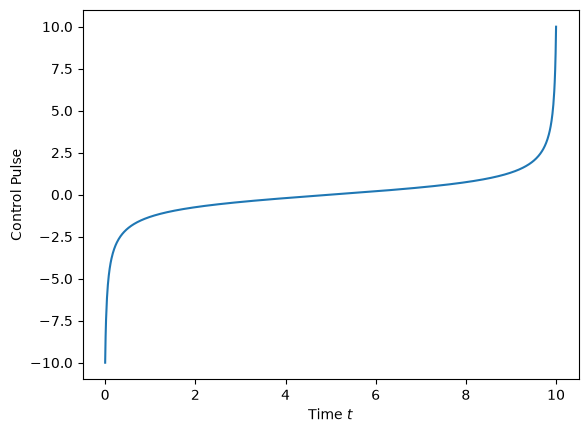

In [4]:
total_time = 10
pulse = model.synthesize_pulse(duration=total_time)
fig, ax = model.synthesize_pulse(duration=total_time, method='plot', pulse_kwargs={'show': True});

## Discretized pulse

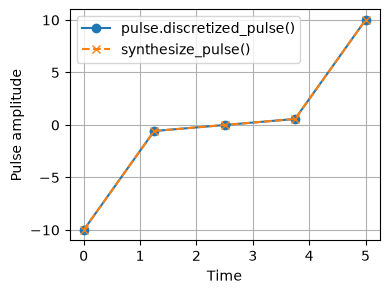

In [8]:
total_time = 5
pulse = model.synthesize_pulse(duration=total_time)

steps = 5
discretized_pulse = pulse.discretized_pulse(linear_steps=steps)
discretized_pulse_direct = model.synthesize_pulse(duration=total_time, method='discretized',
                                                  pulse_kwargs={'linear_steps': steps})

t1, p1 = discretized_pulse
t2, p2 = discretized_pulse_direct

plt.figure(figsize=(4, 3))

# Plot both to verify they match
plt.plot(t1, p1, 'o-', label='pulse.discretized_pulse()')
plt.plot(t2, p2, 'x--', label='synthesize_pulse()')

plt.xlabel("Time")
plt.ylabel("Pulse amplitude")
plt.legend()
plt.grid(True);

## Filtered pulse

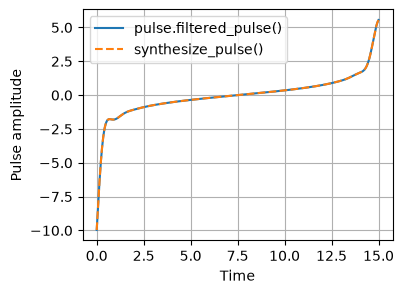

In [9]:
total_time = 15
freq_cut = 1

pulse = model.synthesize_pulse(duration=total_time)
filtered_pulse = pulse.filtered_pulse(freq_cut)
filtered_pulse_direct = model.synthesize_pulse(duration=total_time, method='filtered', pulse_args=(freq_cut,))

plt.figure(figsize=(4, 3))

# Plot both to verify they match
plt.plot(*filtered_pulse, '-', label='pulse.filtered_pulse()')
plt.plot(*filtered_pulse_direct, '--', label='synthesize_pulse()')

plt.xlabel("Time")
plt.ylabel("Pulse amplitude")
plt.legend()
plt.grid(True);

## Fourier spectrum

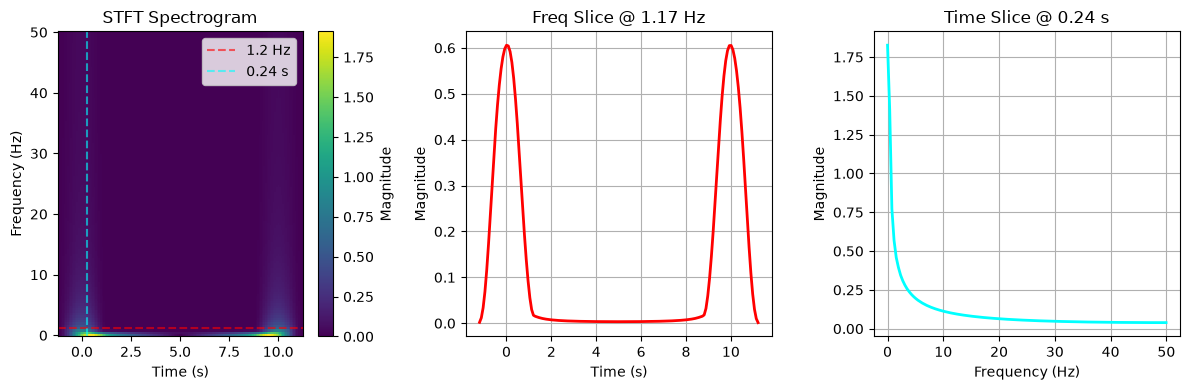

In [10]:
total_time = 10
pulse = model.synthesize_pulse(duration=total_time)
freqs, times, magnitude = pulse.fourier_spectrum(window_len=256, hop=8)

target_freq = 1.0
freq_idx = np.argmin(np.abs(freqs - target_freq))

target_time = 0.25
time_idx = np.argmin(np.abs(times - target_time))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

mesh = axes[0].pcolormesh(times, freqs, magnitude, shading='auto', cmap='viridis')
fig.colorbar(mesh, ax=axes[0], label='Magnitude')
axes[0].axhline(freqs[freq_idx], color='red', linestyle='--', alpha=0.6, label=f'{freqs[freq_idx]:.1f} Hz')
axes[0].axvline(times[time_idx], color='cyan', linestyle='--', alpha=0.6, label=f'{times[time_idx]:.2f} s')
axes[0].legend(loc='upper right')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("STFT Spectrogram")

axes[1].plot(times, magnitude[freq_idx, :], color='red', lw=2)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Magnitude")
axes[1].set_title(f"Freq Slice @ {freqs[freq_idx]:.2f} Hz")
axes[1].grid(True)

axes[2].plot(freqs, magnitude[:, time_idx], color='cyan', lw=2)
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("Magnitude")
axes[2].set_title(f"Time Slice @ {times[time_idx]:.2f} s")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Export pulse

In [12]:
total_time = 10
pulse = model.synthesize_pulse(duration=total_time)
pulse.export_pulse(filename='pulse_data', file_extension='csv', overwrite=True)

[geodesiq] File saved as 'pulse_data.csv' type.


# about() `geodesiq`

In [13]:
gq.about()


geodesiq: geometric optimal control
Authors:            Christian Ventura Meinersen & David Fernandez Fernandez
geodesiq Version:   0.1.0
Python Version:     3.13.12 (cpython)
Number of CPUs:     24
Platform Info:      Linux (6.6.87.2-microsoft-standard-WSL2, x86_64)

Core Dependencies:
Numpy Version:      2.4.6
Scipy Version:      1.17.1
QuTiP Version:      5.3.0
Matplotlib Version: 3.11.0

Please cite geodesiq in your publication:
Your Citation Information Here
